# SciPy Bootcamp — Week 1, Day 3B

##### Continuous Metrics & t-tests
##### Welch's t-test, paired t-test, variance, CUPED variance reduction
##### Visualization philosophy: charts are woven into the analysis at the point of discovery — not appended at the end.
##### Q1 (Welch's t-test on session duration): Simulate a MedPulse A/B test on time-on-article:
# Control: 600 users, lognormal(mean...
##### Q2 (Variance kills power): Demonstrate how variance affects test sensitivity.
# True lift = 0.4 minutes in ...
##### Q3 (Paired t-test): Same 120 HealthLine users measured before and after a site redesign.
# before = np.ra...
##### Q4 (CUPED variance reduction): Simulate pre/post experiment data where pre-experiment behavior correlates with ...
##### Q5 (Choose your test): You are given 4 datasets. For each one: choose the correct test, justify in a co...


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

---

### Q1 — Welch's t-test on session duration

```
Simulate a MedPulse A/B test on time-on-article:
# Control: 600 users, lognormal(mean=1.2, sigma=0.8)
# Treatment: 600 users, lognormal(mean=1.35, sigma=0.75)
# (a) Plot side-by-side histograms of both groups. Does the distribution look normal?
# (b) Run Welch's t-test (equal_var=False, alternative='less').
# (c) Compute Cohen's d effect size.
# (d) Explain in a comment why you use Welch's rather than Student's t-test here.
```


In [ ]:
# Q1: Welch's t-test on session duration
# Chart + analysis woven together — visualize as you discover

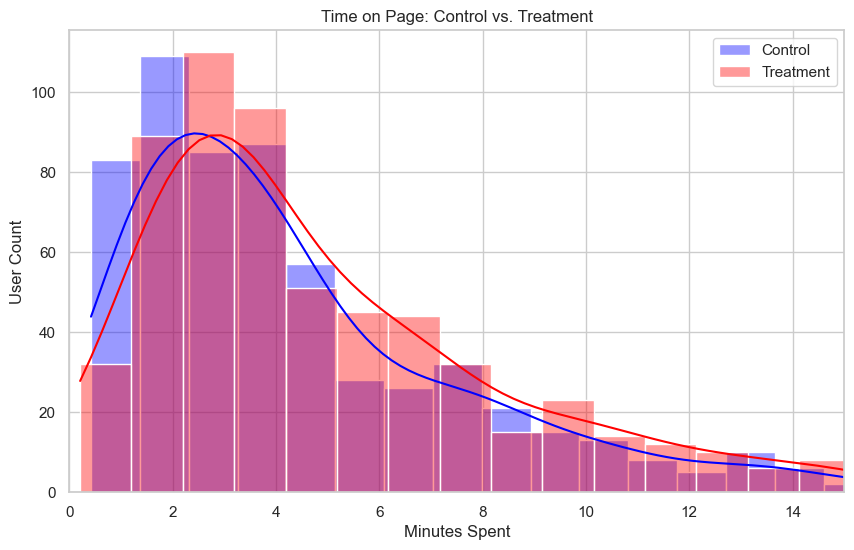

In [ ]:
# (a) Plot side-by-side histograms of both groups. Does the distribution look normal?

# setup data
control   = np.random.lognormal(mean=1.2, sigma=0.8, size=600) # minutes
treatment   = np.random.lognormal(mean=1.35, sigma=0.75, size=600)

# plotting 
plt.figure(figsize=(10,6))

sns.histplot(control, color='blue', label='Control', kde=True, alpha=0.4)
sns.histplot(treatment, color='red', label='Treatment', kde=True, alpha=0.4)

# Lognormal has a "long tail." Without this, the plot looks very squashed.
plt.xlim(0, 15)

plt.xlabel('Minutes Spent')
plt.ylabel('User Count')
plt.title('Time on Page: Control vs. Treatment')
plt.legend()
plt.show()

# The distribution is a textbook example of lognormal which is right-skewed and not bell-shaped

In [21]:
# (b) Run Welch's t-test (equal_var=False, alternative='less').
t_stat, p_value = stats.ttest_ind(control, treatment, equal_var=False, alternative='less')
print(f't-statistic: {t_stat:.4f}')
print(f'p-value:     {p_value:.4f}')


t-statistic: -2.2412
p-value:     0.0126


In [25]:
# (c) Compute Cohen's d effect size.
pooled_std = np.sqrt((np.std(treatment)**2 + np.std(control)**2)/2)
cohens_d = (treatment.mean() - control.mean()) / pooled_std
print(f'Cohen\'s d: {cohens_d:.4}')

Cohen's d: 0.1295


# (d) Explain in a comment why you use Welch's rather than Student's t-test here.
Variances are structurally unequal due to different sigmas
Student's has 2 assumptions, Welch's relaxes exactly one
n=600 means CLT covers the normality concern
Welch's is the safe default with no downside

---

### Q2 — Variance kills power

```
Demonstrate how variance affects test sensitivity.
# True lift = 0.4 minutes in both cases. n=200 per group in both cases.
# Scenario A: std=0.8 minutes. Scenario B: std=3.5 minutes.
# (a) Plot the distribution of both groups for each scenario (2x2 subplot).
# (b) Run Welch's t-test for each scenario. Print both p-values.
# (c) Simulate 1000 experiments for each scenario and compute empirical power.
# (d) What sample size would Scenario B need to match Scenario A's power?
```


In [ ]:
# Q2: Variance kills power
# Chart + analysis woven together — visualize as you discover

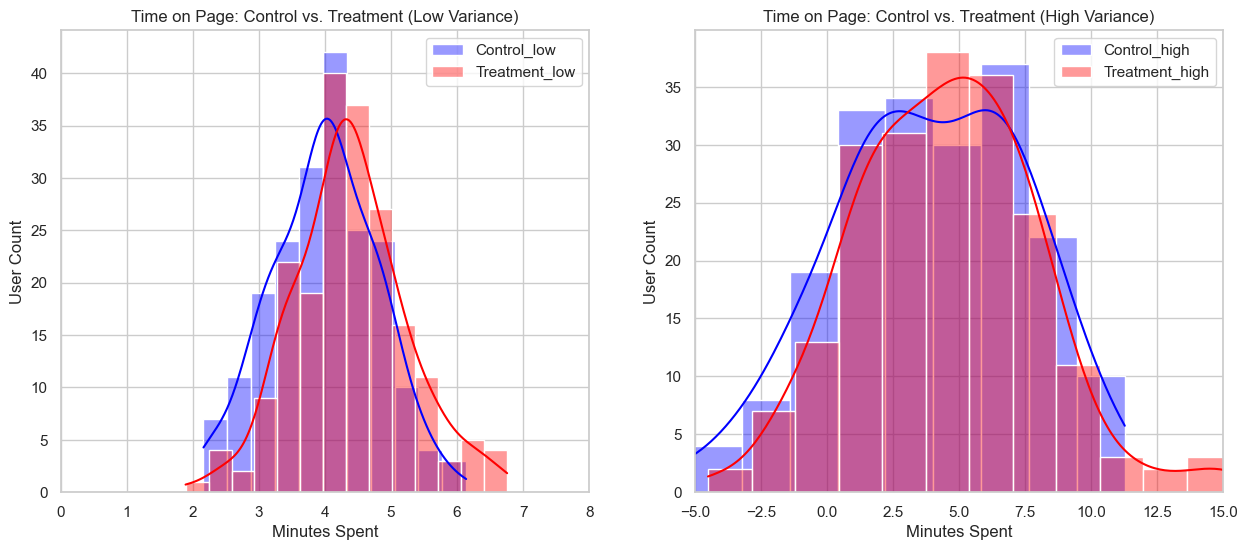

In [40]:
# (a) Plot the distribution of both groups for each scenario (2x2 subplot).

# setup data
# scenario A: Assume mean = 4
control_low = np.random.normal(4, 0.8, 200)
treatment_low = np.random.normal(4.4, 0.8, 200)

# scenario B: Assume mean = 4
control_high = np.random.normal(4, 3.5, 200)
treatment_high = np.random.normal(4.4, 3.5, 200)

# plotting
# scenario A
plt.figure(figsize=(15,6))
plt.subplot(1, 2, 1)
sns.histplot(control_low , color='blue', label='Control_low', kde=True, alpha=0.4)
sns.histplot(treatment_low, color='red', label='Treatment_low', kde=True, alpha=0.4)
plt.xlim(0, 8)
plt.xlabel('Minutes Spent')
plt.ylabel('User Count')
plt.title('Time on Page: Control vs. Treatment (Low Variance)')
plt.legend()

# scenario B 
plt.subplot(1, 2, 2)
sns.histplot(control_high , color='blue', label='Control_high', kde=True, alpha=0.4)
sns.histplot(treatment_high, color='red', label='Treatment_high', kde=True, alpha=0.4)
plt.xlim(-5, 15)
plt.xlabel('Minutes Spent')
plt.ylabel('User Count')
plt.title('Time on Page: Control vs. Treatment (High Variance)')
plt.legend()

plt.show()

In [43]:
# (b) Run Welch's t-test for each scenario. Print both p-values.

_, p_low = stats.ttest_ind(control_low, treatment_low, equal_var=False)
print(f'Low variance  p-value: {p_low:.4f}')

_, p_high = stats.ttest_ind(control_high, treatment_high, equal_var=False)
print(f'High variance  p-value: {p_high:.4f}')

print()
print('Same true lift, same sample size — completely different conclusions!')
print('High variance metrics need much larger samples to reach significance.')

Low variance  p-value: 0.0000
High variance  p-value: 0.0689

Same true lift, same sample size — completely different conclusions!
High variance metrics need much larger samples to reach significance.


In [ ]:
# (c) Simulate 1000 experiments for each scenario and compute empirical power.

control_low = np.random.normal(4, 0.8, (1000, 200))
treatment_low = np.random.normal(4.4, 0.8, (1000, 200))
_, p_vals_low = stats.ttest_ind(control_low, treatment_low, axis=1) # Run 1000 t-tests at once (axis=1 runs it for each row/experiment)
power_low = (p_vals_low < .05).mean()*100

control_high = np.random.normal(4, 3.5, (1000, 200))
treatment_high = np.random.normal(4.4, 3.5, (1000, 200))
_, p_vals_high = stats.ttest_ind(control_high, treatment_high, axis=1)
power_high = (p_vals_high < .05).mean()*100


print(f"Scenario A Power: {power_low:.1f}%")
print(f"Scenario B Power: {power_high:.1f}%")

Scenario A Power: 99.9%
Scenario B Power: 19.6%


In [59]:
# (d) What sample size would Scenario B need to match Scenario A's power?

from statsmodels.stats import power

# Define your Effect Size (Cohen's d)
# Remember: d = (Lift / Standard Deviation)
effect_size_high = 0.4 / 3.5

# 2. Calculate "n"
sample_number = power.TTestIndPower().solve_power(
    effect_size = effect_size_high, 
    power=.8,       # Target success rate
    alpha=0.05,     # Standard p-value threshold
    nobs1=None,  
    ratio=1.0       # Equal sized groups
)

print(f"Users needed per group: {int(sample_number)}")

Users needed per group: 1202


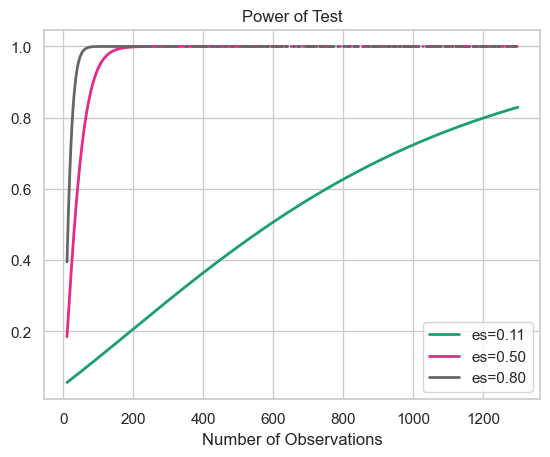

In [86]:
# Plotting the power curve

power.TTestIndPower().plot_power(nobs=np.array(range(10,1300)),effect_size=np.array([effect_size_high, 0.5, 0.8]))
plt.show()

---

### Q3 — Paired t-test

```
Same 120 HealthLine users measured before and after a site redesign.
# before = np.random.normal(3.5, 1.2, 120)
# after  = before + np.random.normal(0.4, 0.6, 120)  # correlated improvement
# (a) Plot a scatter plot of before vs after with a y=x reference line. What does a point above the line mean?
# (b) Plot the distribution of differences (after - before) with a vertical line at 0.
# (c) Run both independent t-test AND paired t-test. Compare p-values.
# (d) Explain in a comment why the paired test gives a smaller p-value here.
```


In [ ]:
# Q3: Paired t-test
# Chart + analysis woven together — visualize as you discover

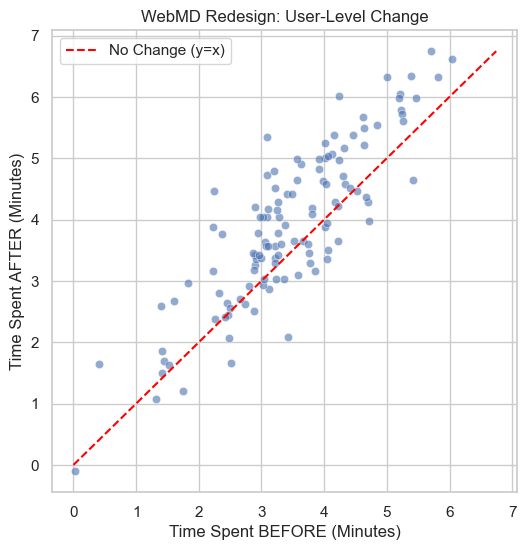

In [ ]:
# (a) Plot a scatter plot of before vs after with a y=x reference line. What does a point above the line mean?

# setup data

before = np.random.normal(3.5, 1.2, 120)
after = before + np.random.normal(0.4, 0.6, 120)

plt.figure(figsize=(6, 6))
sns.scatterplot(x=before, y=after, alpha=.6)

# Add the y=x reference line
# We use the max value of the data to make the line long enough
max_val = max(before.max(), after.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='No Change (y=x)')

plt.xlabel('Time Spent BEFORE (Minutes)')
plt.ylabel('Time Spent AFTER (Minutes)')
plt.title('HealthLine Redesign: User-Level Change')
plt.legend()
plt.show()

# A point above y=x means that user spent more time after the redesign than before (improvement). 
# Points below = regression.

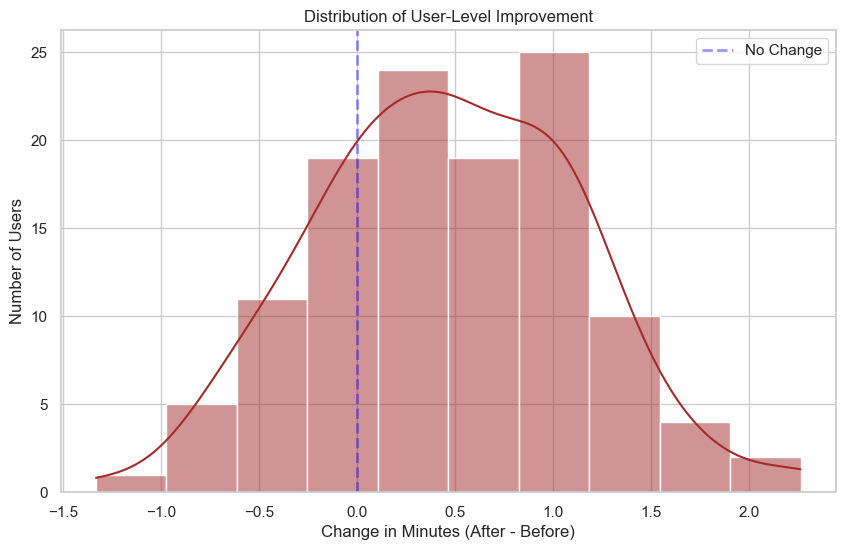

In [116]:
# (b) Plot the distribution of differences (after - before) with a vertical line at 0.

diff = after - before

plt.figure(figsize=(10,6))
sns.histplot(diff, color='brown', kde=True, alpha=.5)
plt.axvline(x=0, color='blue', label='No Change', linestyle='--', linewidth=2, alpha=.4)

plt.title('Distribution of User-Level Improvement')
plt.xlabel('Change in Minutes (After - Before)')
plt.ylabel('Number of Users')
plt.legend()
plt.show()

In [142]:
# (c) Run both independent t-test AND paired t-test. Compare p-values.

_, p_independent = stats.ttest_ind(before, after, equal_var=False)
_, p_paired = stats.ttest_rel(before, after)

print(f'Independent t-test p: {p_independent:.4f}  (ignores user correlation)')
print(f'Paired t-test p:      {p_paired:.4f}  (accounts for user correlation)')

print(f'Mean improvement:     {(after - before).mean():.3f} minutes')
print()

Independent t-test p: 0.0034  (ignores user correlation)
Paired t-test p:      0.0000  (accounts for user correlation)
Mean improvement:     0.460 minutes



# (d) Explain in a comment why the paired test gives a smaller p-value here.
Paired test is more sensitive because each user is their own control.
It eliminates between-user noise. 
Users naturally differ in how long they read. 
That noise inflates variance in an independent test. 
Pairing subtracts it out, leaving only the within-user change signal.

---

### Q4 — CUPED variance reduction

```
Simulate pre/post experiment data where pre-experiment behavior correlates with post (r=0.7).
# n=800 per group. True lift = 0.3 minutes. Both groups should have same pre-experiment mean.
# (a) Run standard Welch's t-test on post-experiment data. Record p-value.
# (b) Implement CUPED: subtract theta*(pre - pre_mean) from each user's post metric.
#     theta = Cov(post, pre) / Var(pre) computed on control group only.
# (c) Run Welch's t-test on CUPED-adjusted metrics. Record p-value.
# (d) Plot variance of control group before and after CUPED adjustment.
# (e) What % variance reduction did CUPED achieve? How did p-value change?
```


In [ ]:
# Q4: CUPED variance reduction
# Chart + analysis woven together — visualize as you discover

Simulate pre/post experiment data where pre-experiment behavior correlates with post (r=0.7).
# n=800 per group. True lift = 0.3 minutes. Both groups should have same pre-experiment mean.

In [ ]:
# (a) Run standard Welch's t-test on post-experiment data. Record p-value.

np.random.seed(420)
n = 800

# Simulate pre-experiment session durations (correlated with post)
pre_exp = np.random.normal(3.0, 1.5, n)

# Post-experiment: control stays same, treatment gets +0.3 lift
noise = np.random.normal(0, 1.2, n)

control_post   = pre_exp[:n//2] * 0.7 + noise[:n//2] + 0.9
treatment_post = pre_exp[n//2:] * 0.7 + noise[n//2:] + 1.2  # +0.3 lift

# Standard t-test
_, p_standard = stats.ttest_ind(control_post, treatment_post, equal_var=False)

print(f'Standard test p-value: {p_standard:.4f}')

Standard test p-value: 0.0131


In [125]:
# (b) Implement CUPED: subtract theta*(pre - pre_mean) from each user's post metric.
#     theta = Cov(post, pre) / Var(pre) computed on control group only.

theta = np.cov(control_post, pre_exp[:n//2])[0,1] / np.var(pre_exp[:n//2])

cuped_control   = control_post   - theta * (pre_exp[:n//2] - pre_exp[:n//2].mean())
cuped_treatment = treatment_post - theta * (pre_exp[n//2:] - pre_exp[n//2:].mean())

In [126]:
# (c) Run Welch's t-test on CUPED-adjusted metrics. Record p-value.

_, p_cuped = stats.ttest_ind(cuped_control, cuped_treatment, equal_var=False)
print(f'CUPED test p-value:    {p_cuped:.4f}')

CUPED test p-value:    0.0012


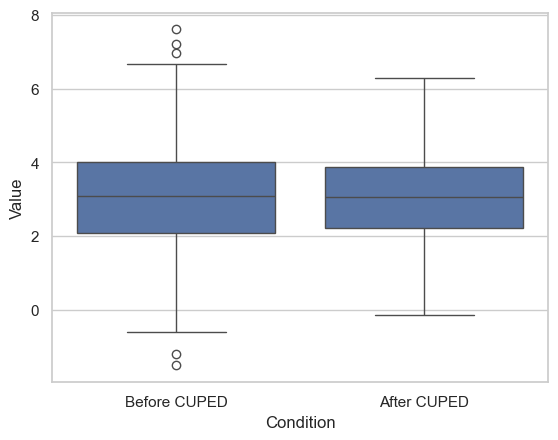

In [137]:
# (d) Plot variance of control group before and after CUPED adjustment.

len_before = len(control_post)
len_after = len(cuped_control)

df = pd.DataFrame({
    'Condition' : ['Before CUPED'] * len_before + ['After CUPED'] * len_after,
    'Value' : np.concatenate([control_post, cuped_control])
})

# plotting
sns.boxplot(df, x='Condition', y='Value')
plt.show()

In [143]:
# (e) What % variance reduction did CUPED achieve? How did p-value change?
print(f'Variance reduction: {(1 - cuped_control.var()/control_post.var()):.1%}')
print(f'p-value improved from 0.0131 to 0.0012, roughly 10x more significant')

Variance reduction: 40.0%
p-value improved from 0.0131 to 0.0012, roughly 10x more significant


---

### Q5 — Choose your test

```
You are given 4 datasets. For each one: choose the correct test
# Dataset A: binary conversion, 2 large groups (n=3000 each)
# Dataset B: session duration, 2 groups, n=15 each, heavily skewed
# Dataset C: satisfaction score 1-5, same users before and after
# Dataset D: revenue per user, 2 groups, n=400 each, extreme outliers present
```


In [ ]:
# Q5: Choose your test

In [ ]:
# Decision summary:
# Dataset A: Two-proportion z-test  — binary outcome, large n
# Dataset B: Mann-Whitney U test    — continuous, n=15, heavily skewed (too small for CLT)
# Dataset C: Paired t-test          — same users before and after
# Dataset D: Welch's t-test after winsorizing — continuous, large n, extreme outliers